# SolarPath — Stage 2, EDA & Feature Engineering

## Part 1 — Merging the Data


**1.1 — Load the 4 CSVs.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.size'] = 10

gen1 = pd.read_csv('Plant_1_Generation_Data.csv')
gen2 = pd.read_csv('Plant_2_Generation_Data.csv')
w1   = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
w2   = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

print(gen1.shape, gen2.shape, w1.shape, w2.shape)

(68778, 7) (67698, 7) (3182, 6) (3259, 6)


**1.2 — Fix the date formats.** Plant 1 uses `DD-MM-YYYY`, everything else uses `YYYY-MM-DD`. Both need to become real `datetime` values before we can merge anything.

In [2]:
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], format='%d-%m-%Y %H:%M')
gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')
w1['DATE_TIME']   = pd.to_datetime(w1['DATE_TIME'],   format='%Y-%m-%d %H:%M:%S')
w2['DATE_TIME']   = pd.to_datetime(w2['DATE_TIME'],   format='%Y-%m-%d %H:%M:%S')

print(gen1['DATE_TIME'].min(), '->', gen1['DATE_TIME'].max())

2020-05-15 00:00:00 -> 2020-06-17 23:45:00


**1.3 — Fix Plant 1's power scale.**

In [3]:
print('Plant1 DC/AC ratio before:', (gen1[gen1.AC_POWER>0].DC_POWER / gen1[gen1.AC_POWER>0].AC_POWER).mean())
gen1['DC_POWER'] = gen1['DC_POWER'] / 10.0
print('Plant1 DC/AC ratio after: ', (gen1[gen1.AC_POWER>0].DC_POWER / gen1[gen1.AC_POWER>0].AC_POWER).mean())
print('Plant2 DC/AC ratio (reference):', (gen2[gen2.AC_POWER>0].DC_POWER / gen2[gen2.AC_POWER>0].AC_POWER).mean())

Plant1 DC/AC ratio before: 10.233664187985054
Plant1 DC/AC ratio after:  1.0233664187985054
Plant2 DC/AC ratio (reference): 1.0237715676627266


**1.4 — Merge generation with weather.**

In [4]:
w1_ = w1.drop(columns=['PLANT_ID', 'SOURCE_KEY'])
w2_ = w2.drop(columns=['PLANT_ID', 'SOURCE_KEY'])

m1 = gen1.merge(w1_, on='DATE_TIME', how='left')
m2 = gen2.merge(w2_, on='DATE_TIME', how='left')

m1['site_id'] = 'PLANT_1_IN'
m2['site_id'] = 'PLANT_2_IN'

raw = pd.concat([m1, m2], ignore_index=True)
raw = raw.rename(columns={
    'DATE_TIME': 'timestamp', 'IRRADIATION': 'irradiation',
    'MODULE_TEMPERATURE': 'temp_module', 'AMBIENT_TEMPERATURE': 'temp_ambient',
    'DC_POWER': 'actual_dc_power'
})
print(raw.shape)

(136476, 11)


**1.5 — Add NASA POWER data (`wind_speed`, `humidity`).**

In [5]:
nasa = pd.read_csv('POWER_Point_Hourly_20200515_20200617_020d76N_072d86E_LST.csv', skiprows=11)
nasa['timestamp'] = pd.to_datetime(dict(year=nasa.YEAR, month=nasa.MO, day=nasa.DY, hour=nasa.HR))
nasa = nasa.rename(columns={
    'WS2M': 'wind_speed', 'RH2M': 'humidity',
    'ALLSKY_SFC_SW_DWN': 'nasa_irradiation_check'
})[['timestamp', 'wind_speed', 'humidity', 'nasa_irradiation_check']]

# Already in LST -- aligns directly with Kaggle local timestamps, no shift needed (checked below)
nasa_15min = nasa.set_index('timestamp').resample('15min').interpolate('linear').reset_index()

raw = raw.merge(nasa_15min, on='timestamp', how='left')

chk = raw.copy(); chk['hour'] = chk['timestamp'].dt.hour
profile = chk.groupby('hour')[['irradiation', 'nasa_irradiation_check']].mean()
print('Peak hour ground vs NASA:', profile['irradiation'].idxmax(), '/', profile['nasa_irradiation_check'].idxmax())
print('Correlation (daylight only):', chk[chk.irradiation>0.01][['irradiation','nasa_irradiation_check']].corr().iloc[0,1].round(3))

raw = raw.sort_values(['site_id', 'SOURCE_KEY', 'timestamp'])
for c in ['wind_speed', 'humidity', 'nasa_irradiation_check']:
    raw[c] = raw.groupby('site_id')[c].transform(lambda s: s.ffill().bfill())  # fixes edges left by the hourly->15min resample

raw = raw.drop(columns=['nasa_irradiation_check'])  # only needed for the check above
raw['latitude'] = 20.76
raw['longitude'] = 72.86
raw = raw.reset_index(drop=True)
print(raw.shape)
raw.head()

Peak hour ground vs NASA: 12 / 11
Correlation (daylight only): 0.799
(136476, 15)


,timestamp,PLANT_ID,SOURCE_KEY,actual_dc_power,AC_POWER,DAILY_YIELD,TOTAL_YIELD,temp_ambient,temp_module,irradiation,site_id,wind_speed,humidity,latitude,longitude
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,PLANT_1_IN,3.0100,69.9100,20.76,72.86
1,2020-05-15 00:15:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.084589,22.761668,0.0,PLANT_1_IN,2.9325,70.5975,20.76,72.86
2,2020-05-15 00:30:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,24.935753,22.592306,0.0,PLANT_1_IN,2.8550,71.2850,20.76,72.86
3,2020-05-15 00:45:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,24.846130,22.360852,0.0,PLANT_1_IN,2.7775,71.9725,20.76,72.86
4,2020-05-15 01:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,24.621525,22.165423,0.0,PLANT_1_IN,2.7000,72.6600,20.76,72.86


**A note on `SOURCE_KEY`.** This is the inverter ID (22 per plant). It's **not a model input** — "
   "it's a random ID that won't mean anything for Egypt's inverters. But it can't be dropped either: "
   "each inverter is its own separate time series, and Day 2's lag/rolling features (`lag_1h`, "
   "`rolling_mean_3h`...) must be computed **per inverter** — mixing readings from two different "
   "inverters into one lag would be wrong. So `SOURCE_KEY` stays as a grouping key, kept out of the "
   "actual feature list when training.

## Part 2 — EDA

**2.1 — `.info()` and `.describe()`**

In [6]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 136476 entries, 0 to 136475
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   timestamp        136476 non-null  datetime64[us]
 1   PLANT_ID         136476 non-null  int64         
 2   SOURCE_KEY       136476 non-null  str           
 3   actual_dc_power  136476 non-null  float64       
 4   AC_POWER         136476 non-null  float64       
 5   DAILY_YIELD      136476 non-null  float64       
 6   TOTAL_YIELD      136476 non-null  float64       
 7   temp_ambient     136472 non-null  float64       
 8   temp_module      136472 non-null  float64       
 9   irradiation      136472 non-null  float64       
 10  site_id          136476 non-null  str           
 11  wind_speed       136476 non-null  float64       
 12  humidity         136476 non-null  float64       
 13  latitude         136476 non-null  float64       
 14  longitude        136476 non-nul

In [7]:
raw.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,136476,2020-06-01 09:23:03.157478,2020-05-15 00:00:00,2020-05-23 23:00:00,2020-06-01 18:45:00,2020-06-09 21:45:00,2020-06-17 23:45:00,NaN
PLANT_ID,136476.0,4135497.04326,4135001.0,4135001.0,4135001.0,4136001.0,4136001.0,499.986176
actual_dc_power,136476.0,280.99151,0.0,0.0,3.638095,543.461667,1447.1125,389.080184
AC_POWER,136476.0,274.803511,0.0,0.0,3.506905,532.673333,1410.95,380.182569
DAILY_YIELD,136476.0,3295.433783,0.0,28.321429,2834.803572,5992.0,9873.0,3035.294425
TOTAL_YIELD,136476.0,330382090.068492,0.0,6520020.0,7269333.0,282609586.0,2247916295.0,608570527.408857
temp_ambient,136472.0,26.763066,20.398505,23.637604,25.908122,29.266583,39.181638,3.89734
temp_module,136472.0,31.920744,18.140415,22.411698,26.413755,40.778583,66.635953,11.803674
irradiation,136472.0,0.230767,0.0,0.0,0.026213,0.442961,1.221652,0.305652
wind_speed,136476.0,3.292616,0.38,2.3625,3.34,4.14,6.97,1.356331


**2.2 — Missing values: how many, and where.**

In [8]:
null_counts = raw.isnull().sum()
print(null_counts[null_counts > 0])

temp_ambient    4
temp_module     4
irradiation     4
dtype: int64


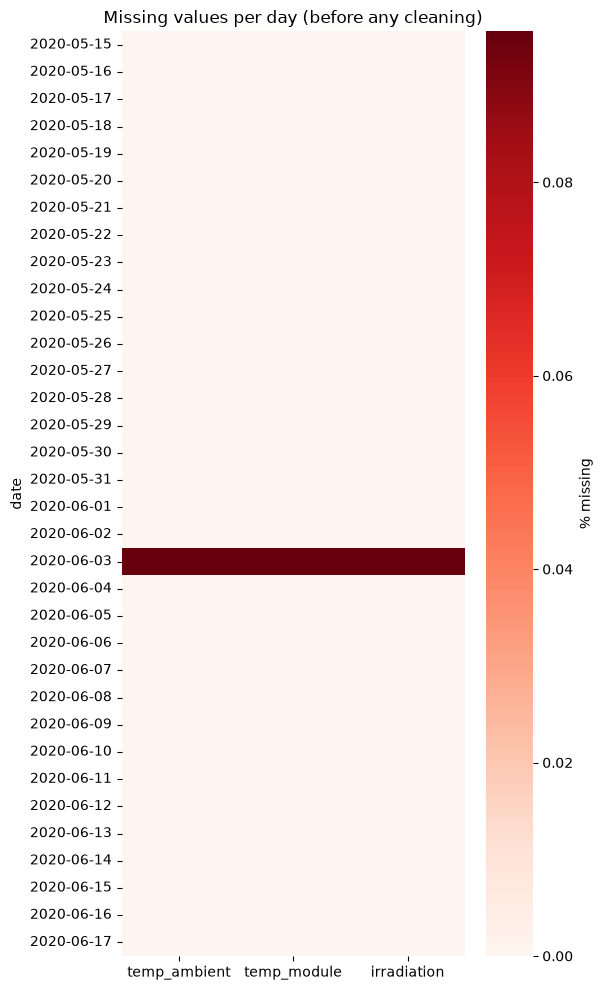

            temp_ambient  temp_module  irradiation
date                                              
2020-06-03      0.095602     0.095602     0.095602


In [9]:
cols_with_nulls = ['temp_ambient', 'temp_module', 'irradiation']
tmp = raw.copy()
tmp['date'] = tmp['timestamp'].dt.date
daily_null_rate = tmp.groupby('date')[cols_with_nulls].apply(lambda g: g.isnull().mean() * 100)

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(daily_null_rate, cmap='Reds', cbar_kws={'label': '% missing'}, ax=ax)
ax.set_title('Missing values per day (before any cleaning)')
plt.tight_layout()
plt.show()

print(daily_null_rate[daily_null_rate.sum(axis=1) > 0])

All the missing values are on **one single day (2020-06-03)** 

**2.3 — Skewness of each feature.**

In [10]:
feature_cols = ['actual_dc_power', 'AC_POWER', 'irradiation', 'temp_ambient', 'temp_module',
                'wind_speed', 'humidity']
print(raw[feature_cols].skew().sort_values(ascending=False))

actual_dc_power    1.150315
AC_POWER           1.145106
irradiation        1.059936
temp_module        0.881348
temp_ambient       0.734230
wind_speed         0.267257
humidity          -0.538739
dtype: float64


**2.4 — Distributions of every feature.**

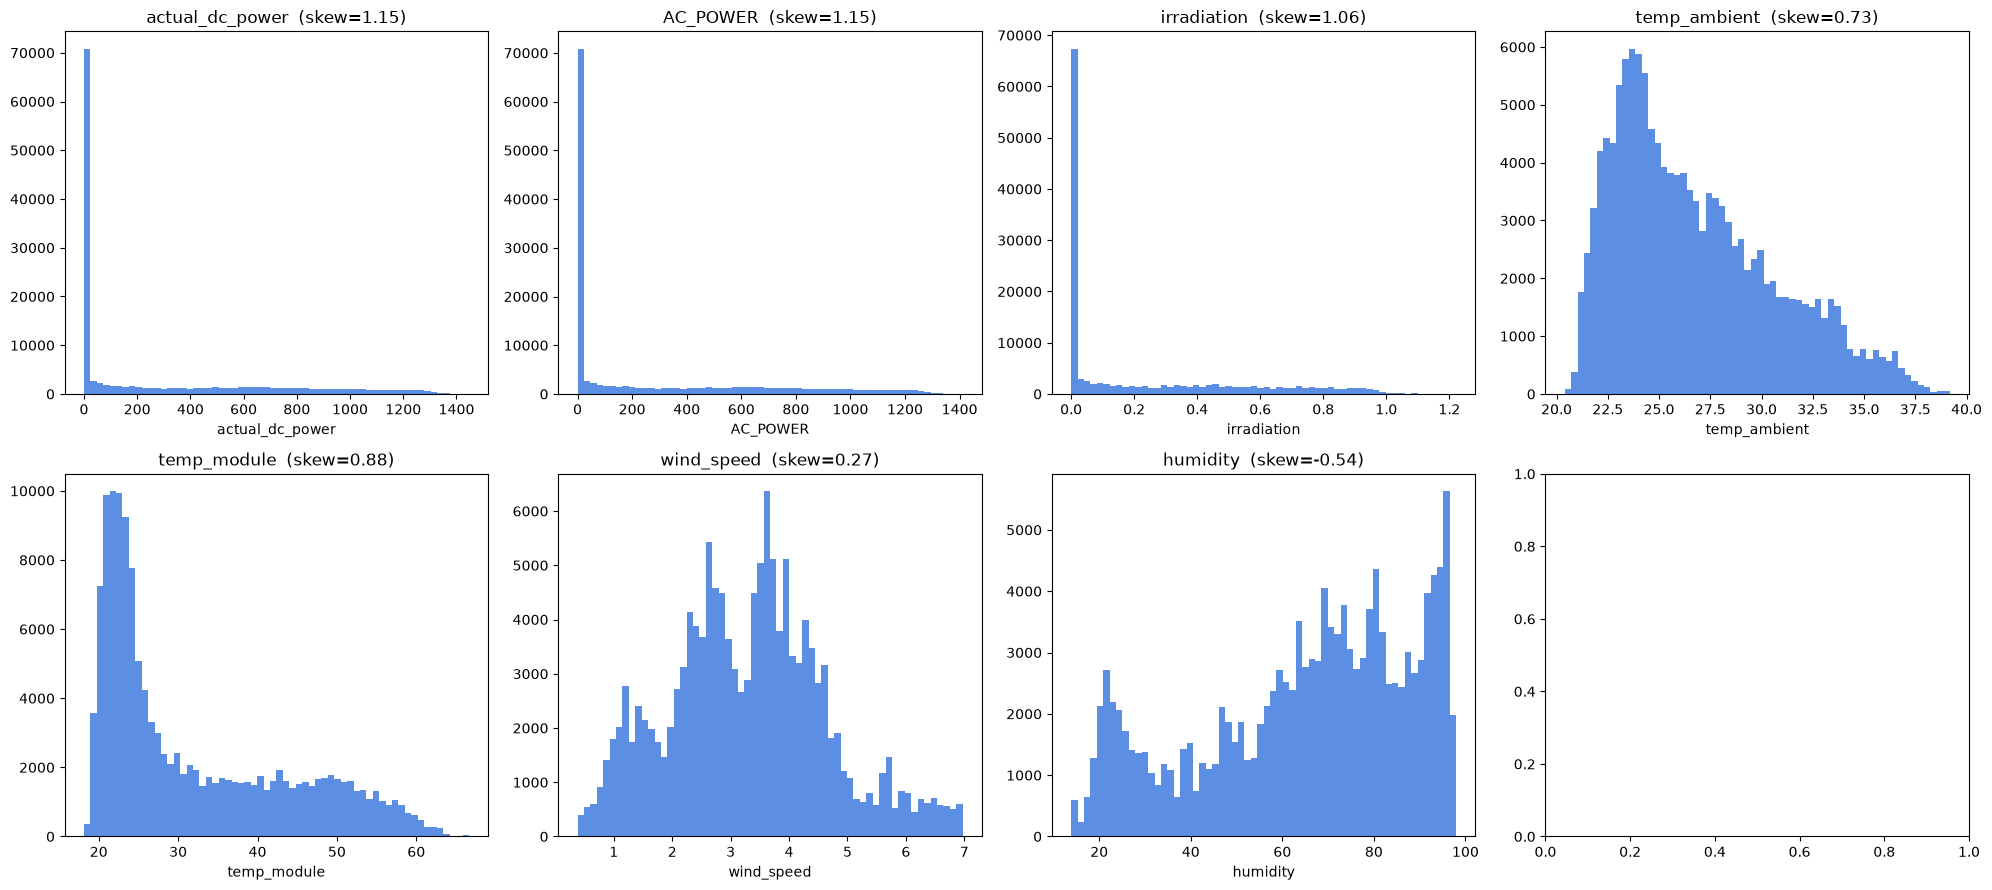

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flatten(), feature_cols):
    ax.hist(raw[col].dropna(), bins=60, color='#3f7ae0', alpha=0.85)
    ax.set_title(f'{col}  (skew={raw[col].skew():.2f})')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

**2.5 — Zero vs. non-zero**


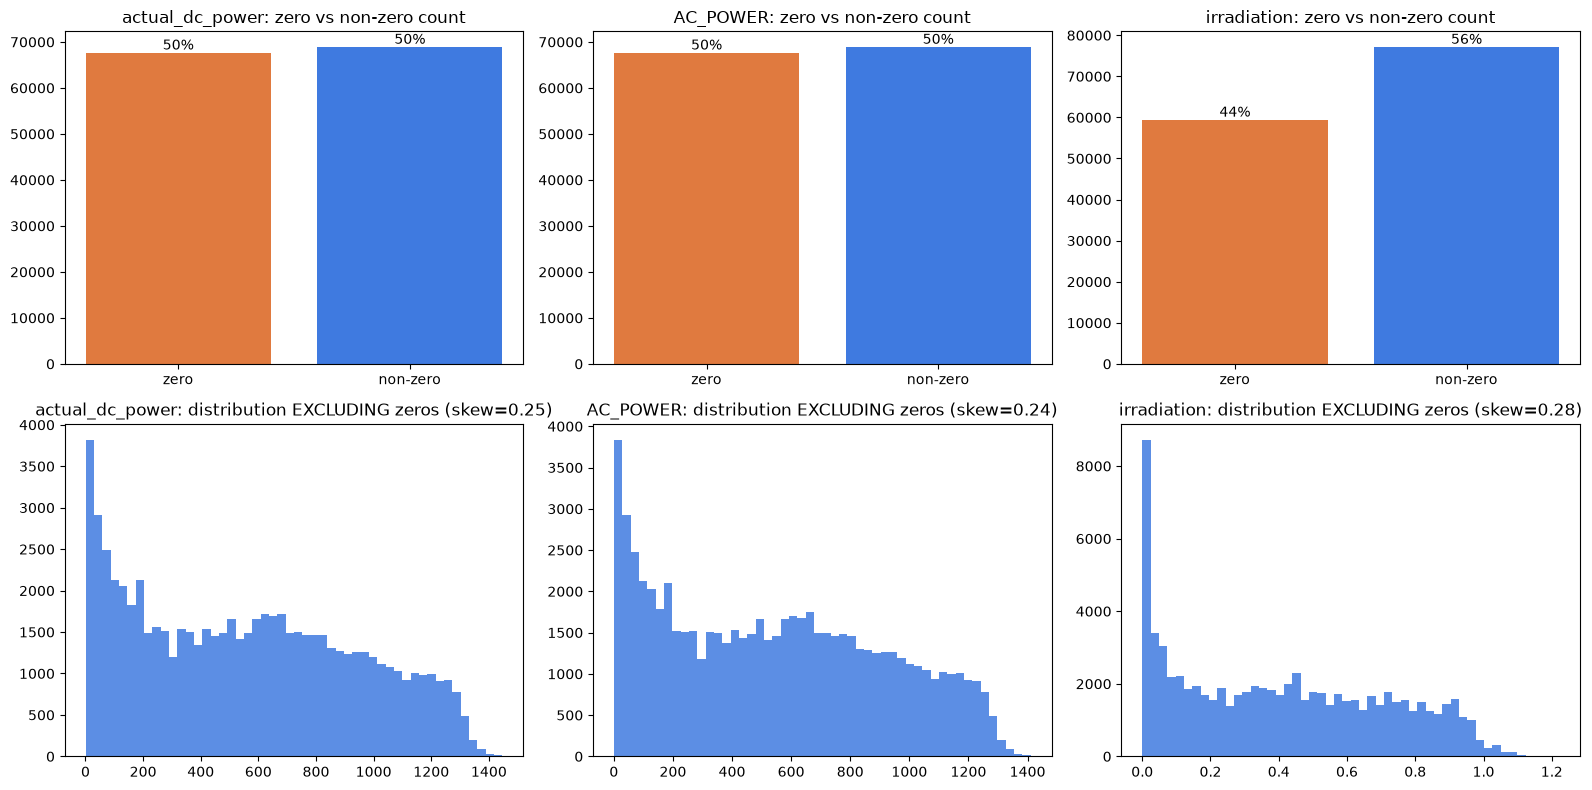

In [12]:
zero_check_cols = ['actual_dc_power', 'AC_POWER', 'irradiation']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(zero_check_cols):
    is_zero = raw[col] == 0
    axes[0, i].bar(['zero', 'non-zero'], [is_zero.sum(), (~is_zero).sum()], color=['#e07a3f', '#3f7ae0'])
    axes[0, i].set_title(f'{col}: zero vs non-zero count')
    for j, v in enumerate([is_zero.sum(), (~is_zero).sum()]):
        axes[0, i].text(j, v, f'{v/len(raw)*100:.0f}%', ha='center', va='bottom')

    axes[1, i].hist(raw.loc[~is_zero, col], bins=50, color='#3f7ae0', alpha=0.85)
    axes[1, i].set_title(f'{col}: distribution EXCLUDING zeros (skew={raw.loc[~is_zero, col].skew():.2f})')
plt.tight_layout()
plt.show()

Once the zeros (night) are excluded, the remaining distributions are much closer to symmetric. **Confirms the earlier high skew is a day/night artifact, not a real property of the daylight data** — so no math transform (log/sqrt) is needed for these features; see Part 3.4.

**2.6 — How do the features relate to each other and to the target?**

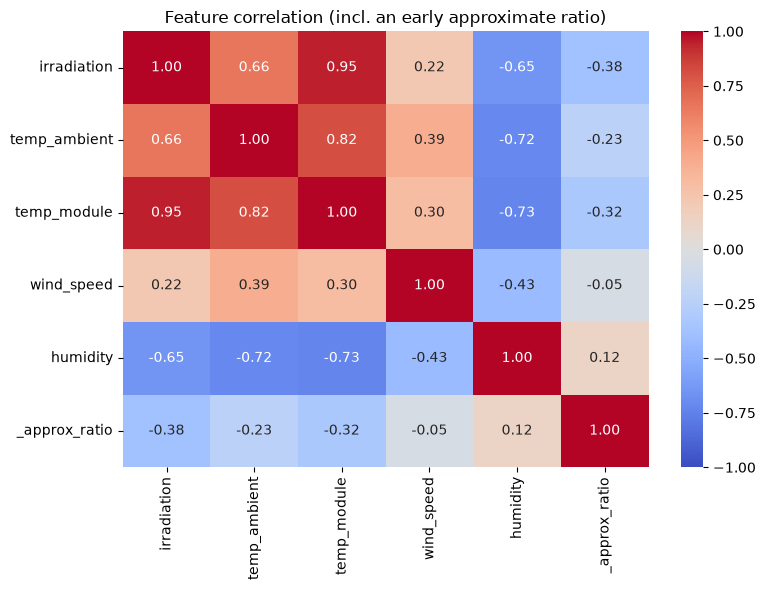

Pairs with |correlation| > 0.7:
  irradiation <-> temp_module: 0.95
  temp_ambient <-> temp_module: 0.82
  temp_ambient <-> humidity: -0.72
  temp_module <-> humidity: -0.73


In [13]:
corr_cols = ['irradiation', 'temp_ambient', 'temp_module', 'wind_speed', 'humidity']
# actual_ratio isn't built yet (that's Part 3) -- approximate it here just to see the relationship shape early
approx_ratio = np.where(raw['irradiation'] > 0.1, raw['actual_dc_power'] / (raw['irradiation'] * 1700), np.nan)
raw['_approx_ratio'] = approx_ratio

corr = raw[corr_cols + ['_approx_ratio']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature correlation (incl. an early approximate ratio)')
plt.tight_layout()
plt.show()

print('Pairs with |correlation| > 0.7:')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {corr.columns[i]} <-> {corr.columns[j]}: {r:.2f}')

raw = raw.drop(columns=['_approx_ratio'])

**What the correlations say:**
- `irradiation` <-> `temp_module` (0.95) and `temp_ambient` <-> `temp_module` (0.82): expected —
  sunlight heats the panel, and ambient heat contributes too. Real physics, not redundant noise.
- `temp_ambient`/`temp_module` <-> `humidity` (~ -0.72 to -0.73): also expected — hot hours tend to be
  drier in this climate.

**Decision: keep all features, drop none.** `irradiation` and `temp_module` are correlated but not
identical — module temperature also depends on wind cooling and thermal lag, so it carries information
irradiation alone doesn't. Tree models aren't hurt by this. The one place it matters is the Ridge
meta-model in Day 3 — flagged here so whoever builds that step is aware, but Ridge's L2 penalty already
handles moderate multicollinearity reasonably, so no feature needs to be dropped now.

**Update:** `soil_wetness` was dropped from the feature set (Part 1.5) to stay consistent with Stage 1's final features. The correlation numbers above were computed before this notebook was re-run with the new NASA file -- re-run Part 2.6 once and confirm the remaining pairwise values haven't shifted meaningfully.

## Part 3 — Cleaning & Feature Engineering

**3.1 — Drop the rows with no weather match.**

In [14]:
raw = raw.dropna(subset=['irradiation', 'temp_ambient', 'temp_module']).reset_index(drop=True)
print(raw.shape, '| remaining nulls:', raw.isnull().sum().sum())

(136472, 15) | remaining nulls: 0


**3.2 — What to do about night (the zero spike)?**

In [15]:
raw['is_daylight'] = raw['irradiation'] > 0.01
print(raw['is_daylight'].value_counts(normalize=True))

is_daylight
True     0.518231
False    0.481769
Name: proportion, dtype: float64


**3.3 — Build the `Performance_Ratio` target.**

In [16]:
calib = {}
for site, g in raw.groupby('site_id'):
    daylight = g[g['irradiation'] > 0.1]
    calib[site] = np.percentile(daylight['actual_dc_power'] / daylight['irradiation'], 99)
print('Calibration constants:', calib)

raw['K_ref'] = raw['site_id'].map(calib)
raw['theoretical_power'] = raw['irradiation'] * raw['K_ref']
raw['actual_ratio'] = np.where(raw['theoretical_power'] > 1e-6,
                                raw['actual_dc_power'] / raw['theoretical_power'], 0.0)
raw.loc[~raw['is_daylight'], 'actual_ratio'] = 0.0
raw['actual_ratio'] = raw['actual_ratio'].clip(lower=0, upper=1.2)

raw.loc[raw.is_daylight, ['site_id','irradiation','actual_dc_power','theoretical_power','actual_ratio']].describe()

Calibration constants: {'PLANT_1_IN': np.float64(1695.1692572948969), 'PLANT_2_IN': np.float64(1690.7256046257205)}


,irradiation,actual_dc_power,theoretical_power,actual_ratio
count,70724.000000,70724.000000,70724.000000,70724.000000
mean,0.445062,541.994629,753.480968,0.770815
std,0.291465,388.194292,493.408013,0.214440
min,0.010051,0.000000,17.037953,0.000000
25%,0.181857,181.449375,307.471008,0.766255
50%,0.428555,517.793750,726.143162,0.823311
75%,0.685953,849.760714,1160.930887,0.872323
max,1.221652,1447.112500,2070.906654,1.200000


**3.4 — Do we need a log/sqrt transform?**

Two reasons no:
1. Part 2.5 showed the high skew was the day/night split, not a real property of the data — daylight-only
   skew is already low.


**Decision: no transform.**

In [17]:
daylight_df = raw[raw.is_daylight]
print(daylight_df[feature_cols].skew().sort_values(ascending=False))

actual_dc_power    0.265709
AC_POWER           0.257904
temp_ambient       0.240486
irradiation        0.215506
wind_speed         0.189405
temp_module        0.064616
humidity          -0.070955
dtype: float64


**3.5 — Outliers.** Checked with IQR bounds on daylight rows, for every feature:

In [18]:
outlier_summary = {}
for c in feature_cols + ['actual_ratio']:
    q1, q3 = daylight_df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    pct = ((daylight_df[c] < low) | (daylight_df[c] > high)).mean() * 100
    outlier_summary[c] = (round(low,2), round(high,2), round(pct,2))
pd.DataFrame(outlier_summary, index=['low_bound','high_bound','pct_outliers']).T

,low_bound,high_bound,pct_outliers
actual_dc_power,-821.02,1852.23,0.00
AC_POWER,-802.48,1811.33,0.00
irradiation,-0.57,1.44,0.00
temp_ambient,17.87,39.94,0.00
temp_module,4.74,75.73,0.00
wind_speed,0.16,6.78,1.52
humidity,-26.24,125.47,0.00
actual_ratio,0.61,1.03,8.73


In [19]:
wind_cap = daylight_df['wind_speed'].quantile(0.995)
raw['wind_speed'] = raw['wind_speed'].clip(upper=wind_cap)
print(f'wind_speed capped at {wind_cap:.2f} m/s (99.5th pct) — max is now:', raw['wind_speed'].max())

wind_speed capped at 6.92 m/s (99.5th pct) — max is now: 6.9175


## Part 4 — Final Checks

One last pass on the cleaned data: duplicates, missing timestamps, impossible values, and whether `TOTAL_YIELD` behaves like a real cumulative counter.

In [20]:
print('Exact duplicate rows:', raw.duplicated().sum())
print('Duplicate (timestamp, site_id, SOURCE_KEY):', raw.duplicated(subset=['timestamp','site_id','SOURCE_KEY']).sum())
print('Negative actual_dc_power:', (raw.actual_dc_power < 0).sum())
print('AC_POWER > actual_dc_power (>2% tolerance):', (raw.AC_POWER > raw.actual_dc_power * 1.02).sum())

s = raw.sort_values(['site_id','SOURCE_KEY','timestamp']).copy()
s['total_yield_diff'] = s.groupby(['site_id','SOURCE_KEY'])['TOTAL_YIELD'].diff()
print('TOTAL_YIELD counter resets:', (s['total_yield_diff'] < -1000).sum(), '-> excluded from features for this reason.')

Exact duplicate rows: 0
Duplicate (timestamp, site_id, SOURCE_KEY): 0
Negative actual_dc_power: 0
AC_POWER > actual_dc_power (>2% tolerance): 2
TOTAL_YIELD counter resets: 1161 -> excluded from features for this reason.


**Sanity check on the engineered target** — it should center around 0.75–0.85 in daylight, dip with heat, and separate the known weak inverters. All confirmed below.

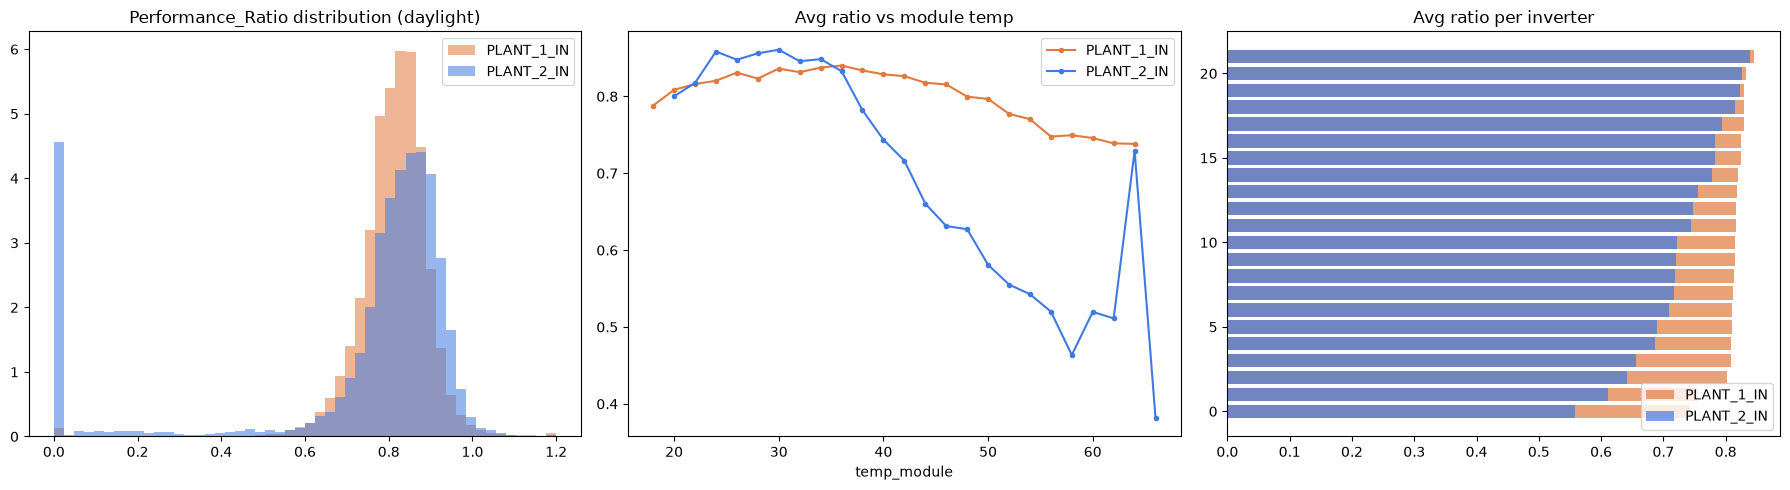

In [21]:
day = raw[raw.is_daylight]
colors = {'PLANT_1_IN': '#e07a3f', 'PLANT_2_IN': '#3f7ae0'}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for site in raw.site_id.unique():
    ax.hist(day[day.site_id==site]['actual_ratio'], bins=50, alpha=0.55, label=site, color=colors[site], density=True)
ax.set_title('Performance_Ratio distribution (daylight)'); ax.legend()

ax = axes[1]
for site in raw.site_id.unique():
    d = day[day.site_id==site].groupby(day[day.site_id==site]['temp_module']//2*2)['actual_ratio'].mean()
    ax.plot(d.index, d.values, color=colors[site], label=site, marker='o', markersize=3)
ax.set_title('Avg ratio vs module temp'); ax.set_xlabel('temp_module'); ax.legend()

ax = axes[2]
inv = day.groupby(['site_id','SOURCE_KEY'])['actual_ratio'].mean().reset_index()
for site in raw.site_id.unique():
    d = inv[inv.site_id==site].sort_values('actual_ratio')
    ax.barh(range(len(d)), d['actual_ratio'], color=colors[site], alpha=0.7, label=site)
ax.set_title('Avg ratio per inverter'); ax.legend()
plt.tight_layout()
plt.show()

## Part 5 — Save

Full schema, all rows kept (including night — see 3.2). `SOURCE_KEY` is kept as a grouping key for Day 2's per-inverter lag features, but should not be used as a model input.

In [22]:
final_cols = ['timestamp', 'site_id', 'SOURCE_KEY', 'latitude', 'longitude',
              'irradiation', 'temp_ambient', 'temp_module', 'wind_speed', 'humidity',
              'actual_dc_power', 'AC_POWER', 'theoretical_power', 'actual_ratio', 'is_daylight']
final = raw[final_cols].rename(columns={'AC_POWER': 'actual_ac_power'})
final.to_csv('solarpath_day1_clean_dataset.csv', index=False)
print(final.shape)
final.head()

(136472, 15)


,timestamp,site_id,SOURCE_KEY,latitude,longitude,irradiation,temp_ambient,temp_module,wind_speed,humidity,actual_dc_power,actual_ac_power,theoretical_power,actual_ratio,is_daylight
0,2020-05-15 00:00:00,PLANT_1_IN,1BY6WEcLGh8j5v7,20.76,72.86,0.0,25.184316,22.857507,3.0100,69.9100,0.0,0.0,0.0,0.0,False
1,2020-05-15 00:15:00,PLANT_1_IN,1BY6WEcLGh8j5v7,20.76,72.86,0.0,25.084589,22.761668,2.9325,70.5975,0.0,0.0,0.0,0.0,False
2,2020-05-15 00:30:00,PLANT_1_IN,1BY6WEcLGh8j5v7,20.76,72.86,0.0,24.935753,22.592306,2.8550,71.2850,0.0,0.0,0.0,0.0,False
3,2020-05-15 00:45:00,PLANT_1_IN,1BY6WEcLGh8j5v7,20.76,72.86,0.0,24.846130,22.360852,2.7775,71.9725,0.0,0.0,0.0,0.0,False
4,2020-05-15 01:00:00,PLANT_1_IN,1BY6WEcLGh8j5v7,20.76,72.86,0.0,24.621525,22.165423,2.7000,72.6600,0.0,0.0,0.0,0.0,False


## Part 7 — Building the Training Datasets

**7.1 — Drop `theoretical_power` (and `K_ref`).**

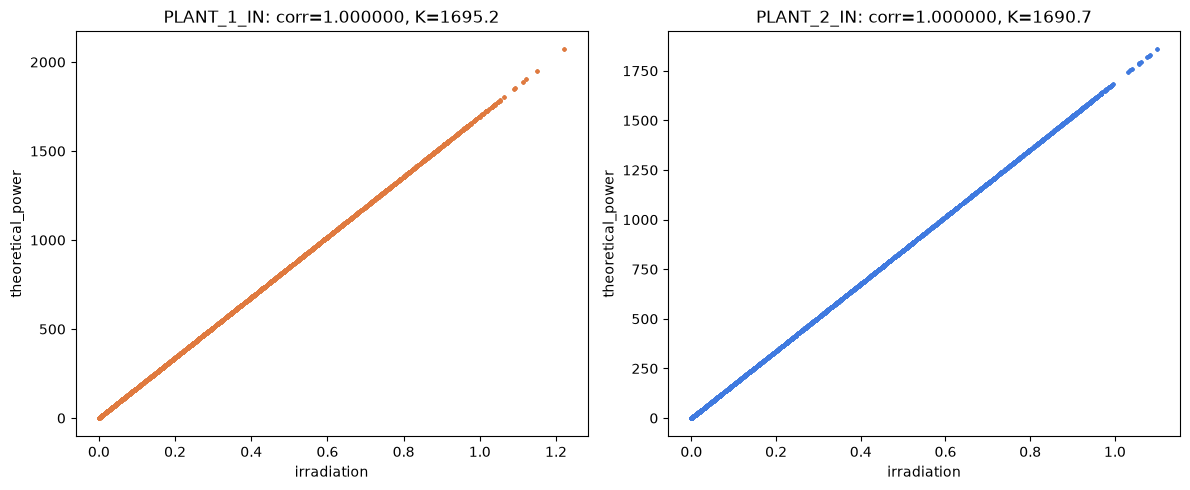

-> Perfectly linear, dropping theoretical_power and K_ref.


In [23]:
colors = {'PLANT_1_IN': '#e07a3f', 'PLANT_2_IN': '#3f7ae0'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, site in zip(axes, raw.site_id.unique()):
    d = raw[raw.site_id == site]
    ax.scatter(d['irradiation'], d['theoretical_power'], s=3, alpha=0.3, color=colors[site])
    r = d[['irradiation', 'theoretical_power']].corr().iloc[0, 1]
    k_vals = d['K_ref'].unique()
    ax.set_title(f'{site}: corr={r:.6f}, K={k_vals[0]:.1f}')
    ax.set_xlabel('irradiation'); ax.set_ylabel('theoretical_power')
plt.tight_layout()
plt.show()
plt.close('all')

print('-> Perfectly linear, dropping theoretical_power and K_ref.')
raw = raw.drop(columns=['theoretical_power', 'K_ref'])

In [ ]:
# Drop extra columns (PLANT_ID, DAILY_YIELD, TOTAL_YIELD) and rename AC_POWER to actual_ac_power
save_cols = [c for c in raw.columns if c not in ['PLANT_ID', 'DAILY_YIELD', 'TOTAL_YIELD', 'K_ref', 'theoretical_power']]
raw_save = raw[save_cols].rename(columns={'AC_POWER': 'actual_ac_power'})
raw_save.to_csv('solarpath_day1_clean_dataset.csv', index=False)
seq_cols = ['timestamp', 'site_id', 'SOURCE_KEY', 'irradiation', 'temp_ambient', 'temp_module',
            'wind_speed', 'humidity', 'actual_ratio', 'is_daylight']
sequence_df = raw[seq_cols].copy()
sequence_df.to_csv('sequence_dataset.csv', index=False)
print("Main Clean Dataset Shape:", raw_save.shape)
print("Sequence Dataset Shape:", sequence_df.shape)


Main Clean Dataset Shape: (136472, 14)
Sequence Dataset Shape: (136472, 10)
